# Chicago Cab Trips Analysis

## Data Import, Exploration, and Cleaning

In [19]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats as st

In [20]:
df_trips = pd.read_csv('data/sql_result_01.csv')
df_avg_trips = pd.read_csv('data/sql_result_04.csv')

df_trips.info()
df_avg_trips.info()


<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 2.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 2.6 KB


In [21]:
df_trips.isna().sum()
df_avg_trips.isna().sum()
df_trips.duplicated().sum()
df_avg_trips.duplicated().sum()

np.int64(0)

In [22]:
#Aqui limpiamos los nombres quitando los numeros y caracteres innecesarios
trips_amount = df_trips
trips_amount['company_name'] = trips_amount['company_name'].str.strip('.')
trips_amount['company_name'] = trips_amount['company_name'].str.replace(r'\d{1,5} - ', '', regex=True)
trips_amount['company_name'] = trips_amount['company_name'].str.replace(r'\d{5} ', '', regex=True)

avg_drops = df_avg_trips
avg_drops['average_trips'] = avg_drops['average_trips'].round(2)


## Data Exploration

In [23]:
trips_amount.head(10)

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc,5953


In [24]:
avg_drops.head(10)

,dropoff_location_name,average_trips
0,Loop,10727.47
1,River North,9523.67
2,Streeterville,6664.67
3,West Loop,5163.67
4,O'Hare,2546.90
5,Lake View,2420.97
6,Grant Park,2068.53
7,Museum Campus,1510.00
8,Gold Coast,1364.23
9,Sheffield & DePaul,1259.77


## Chart Creation and Analysis

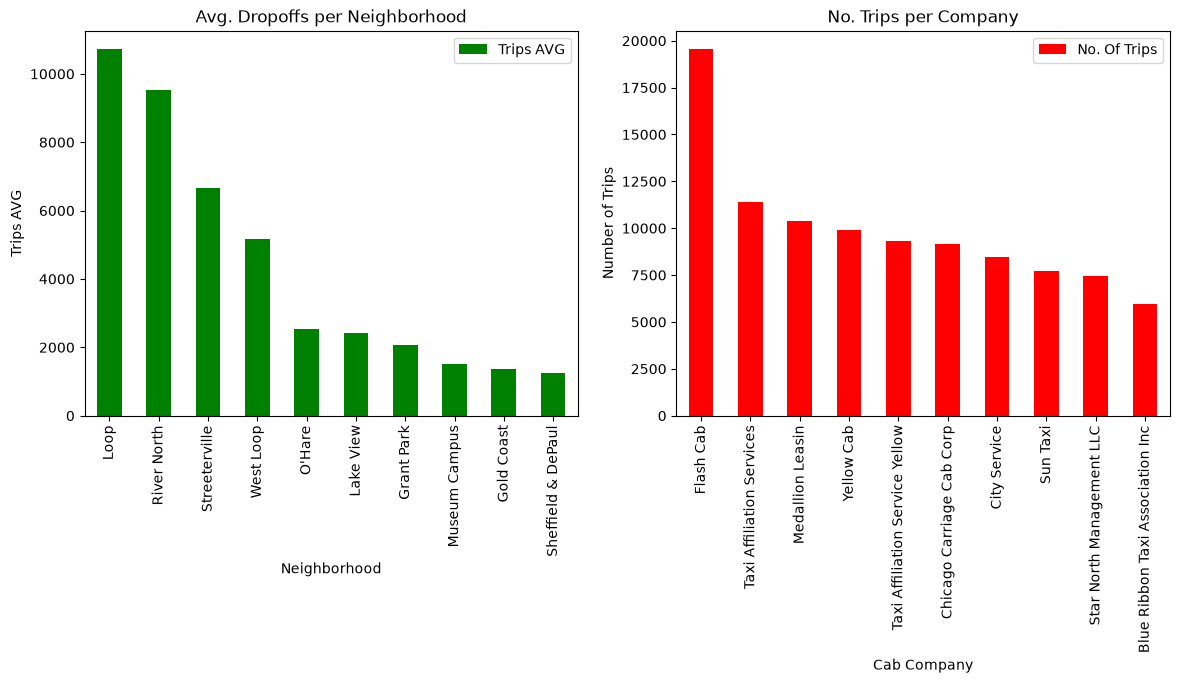

In [25]:
#Aqui ponemos las dos tablas juntas para poder observar ambas al mismo tiempo de manera mas practica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
avg_drops.head(10).plot(kind = 'bar', x = 'dropoff_location_name',y = 'average_trips',xlabel = 'Neighborhood',ylabel = 'Trips AVG',title = 'Avg. Dropoffs per Neighborhood',label = 'Trips AVG',color = 'green',ax=ax1)
trips_amount.head(10).plot(kind = 'bar', x = 'company_name',y = 'trips_amount',xlabel = 'Cab Company',ylabel = 'Number of Trips',title = 'No. Trips per Company',label = 'No. Of Trips',color = 'red',ax=ax2)
plt.show()

## Data Analysis Conclusion

#### AVG Dropoff per Neighborhood
The chart shows two spikes in the Loop and River North neighborhoods, with Loop clearly the most requested destination because it exceeds an average of over 10k trips. River North remains close behind, averaging about 9,500 trips, roughly 1,200 trips less than Loop.

Then there are two neighborhoods that stand above the rest, with average trips around 6,600 and 5,000. Streeterville and West Loop are the top four most requested neighborhoods.

The remaining neighborhoods fall below an average of 3,000 trips, indicating a more balanced distribution of travel demand.

#### Number of Trips by Company
Here we see a clear preference for Flash Cab, which has nearly 20k trips, with an actual total of 19,558 trips. That leaves the closest competitor, Taxi Affiliation Services, about 8k trips behind, and most of the remaining companies nearly half as many.

Among the other companies, competition is more evenly distributed. Between Medallion Leasing and Chicago Carriage Cab Corp, the difference is no more than 1,300 trips, making them the companies with the most direct competition.

The 7th, 8th, and 9th ranked companies do not exceed 9k trips, but they are strongly competing with each other for relevance, even though it is not enough to challenge the top six companies.

Finally, Blue Ribbon Taxi Association Inc. is much less relevant, remaining well below the average competition level of the top 10.




# Hypothesis Testing

## Data Import and Cleaning

In [26]:
df_weather = pd.read_csv('data/sql_result_07.csv')

df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   str    
 1   weather_conditions  1068 non-null   str    
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), str(2)
memory usage: 49.0 KB


In [27]:
print(df_weather)

df_weather['start_ts'] = pd.to_datetime(df_weather['start_ts'])

df_weather.info()

                 start_ts weather_conditions  duration_seconds
0     2017-11-25 16:00:00               Good            2410.0
1     2017-11-25 14:00:00               Good            1920.0
2     2017-11-25 12:00:00               Good            1543.0
3     2017-11-04 10:00:00               Good            2512.0
4     2017-11-11 07:00:00               Good            1440.0
...                   ...                ...               ...
1063  2017-11-25 11:00:00               Good               0.0
1064  2017-11-11 10:00:00               Good            1318.0
1065  2017-11-11 13:00:00               Good            2100.0
1066  2017-11-11 08:00:00               Good            1380.0
1067  2017-11-04 16:00:00                Bad            2834.0

[1068 rows x 3 columns]
<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_t

In [28]:
#Aqui me aseguré que las fechas fueran efectivamente sabado, importa marcar que olvide que ya habiamos filtrado esto en SQL
df_weather = df_weather[df_weather['start_ts'].dt.dayofweek == 5]
print(df_weather)

                start_ts weather_conditions  duration_seconds
0    2017-11-25 16:00:00               Good            2410.0
1    2017-11-25 14:00:00               Good            1920.0
2    2017-11-25 12:00:00               Good            1543.0
3    2017-11-04 10:00:00               Good            2512.0
4    2017-11-11 07:00:00               Good            1440.0
...                  ...                ...               ...
1063 2017-11-25 11:00:00               Good               0.0
1064 2017-11-11 10:00:00               Good            1318.0
1065 2017-11-11 13:00:00               Good            2100.0
1066 2017-11-11 08:00:00               Good            1380.0
1067 2017-11-04 16:00:00                Bad            2834.0

[1068 rows x 3 columns]


## Data Preparation and Hypothesis Testing

In [29]:
#Aqui preparamos los datos para los array que ocupa el test para la hipotesis
bad_weather = df_weather[df_weather['weather_conditions'] == 'Bad']
good_weather = df_weather[df_weather['weather_conditions'] == 'Good']

print(bad_weather)
print(good_weather)

                start_ts weather_conditions  duration_seconds
6    2017-11-04 16:00:00                Bad            2969.0
30   2017-11-18 12:00:00                Bad            1980.0
34   2017-11-04 17:00:00                Bad            2460.0
51   2017-11-04 16:00:00                Bad            2760.0
52   2017-11-18 12:00:00                Bad            2460.0
...                  ...                ...               ...
1031 2017-11-18 12:00:00                Bad            2560.0
1032 2017-11-18 10:00:00                Bad            1908.0
1053 2017-11-18 12:00:00                Bad            2400.0
1061 2017-11-18 16:00:00                Bad            2186.0
1067 2017-11-04 16:00:00                Bad            2834.0

[180 rows x 3 columns]
                start_ts weather_conditions  duration_seconds
0    2017-11-25 16:00:00               Good            2410.0
1    2017-11-25 14:00:00               Good            1920.0
2    2017-11-25 12:00:00               Good   

In [30]:
st.ttest_ind(bad_weather['duration_seconds'], good_weather['duration_seconds'])

TtestResult(statistic=np.float64(6.946177714041499), pvalue=np.float64(6.517970327099489e-12), df=np.float64(1066.0))

### Hypothesis Conclusion

I used the null hypothesis because it helps determine whether there is a difference in trip duration based on weather. The hypothesis suggests a direct relationship between weather and trip duration; we used alpha = .05 because it was the most appropriate given the data size.

In conclusion, rejecting the null hypothesis supports the alternative hypothesis, indicating that there is a difference in trip duration between good and bad weather.